In [1]:
#libraries
import numpy as np
import matplotlib.pyplot as plt
import libs
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [2]:
# Set global theme settings for plotting
plt.rcParams.update({
    'font.size': 20,          # Set font size
    'lines.linewidth': 3,     # Set default line thickness
    'axes.titlesize': 20,     # Title font size
    'axes.labelsize': 18,     # Axis label font size
    'xtick.labelsize': 14,    # X-tick label font size
    'ytick.labelsize': 14,    # Y-tick label font size
    'grid.color': 'gray',     # Grid color
    'grid.linestyle': '--',   # Grid line style
    'grid.linewidth': 0.5,    # Grid line width
    'legend.fontsize': 16     # Legend font size
})

In [3]:
Uds = np.array([2.0, 5.0, 10.0])
human_popsize = 10000
iterations = 1000

Kim_sd = 0.009
Boyko_sd = 0.029

Galeotassd_upper = 0.01/2
Galeotassd_lower = 0.0001/2

Chenluetal_noncodingsd = 0.00063

mixedlower_sd = 0.3*Kim_sd + 0.70*Chenluetal_noncodingsd
mixedupper_sd = 0.4*Boyko_sd + 0.6*Chenluetal_noncodingsd

sds = np.array([mixedlower_sd, mixedupper_sd, Boyko_sd])

epistasis_degree = np.linspace(1.0, 1.1, 30)

#x is the number of segregating mutations per individual
#mixedlower_xmean = -Uds/mixedlower_sd
#mixedupper_xmean = -Uds/mixedupper_sd



#print(mixedlower_sd)
#print(mixedlower_xmean[0])


In [4]:
Ud_sd_epistasis_grid = np.meshgrid(Uds, sds, epistasis_degree)
allUds = Ud_sd_epistasis_grid[0].flatten()
allsds = Ud_sd_epistasis_grid[1].flatten()
allepistasis = Ud_sd_epistasis_grid[2].flatten()
allxmeans = allUds/allsds

In [5]:
average_xmin, average_xmax = libs.vget_median_min_max_poisson_sample(allxmeans, human_popsize, iterations)
#vget_best_fitness assumes sd is negative, so we invert it
Wbest = libs.vget_best_fitness(allxmeans, average_xmin, average_xmax, -allsds, allepistasis)
eliminatedperselectivedeaths = allUds/(1.0 - 1.0/Wbest) 

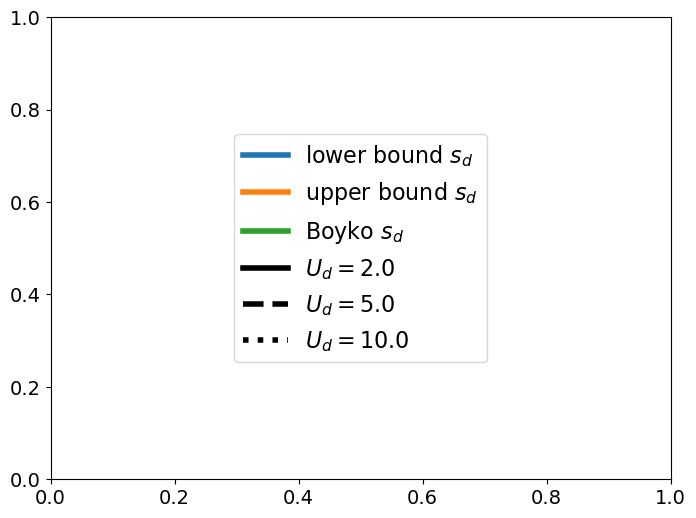

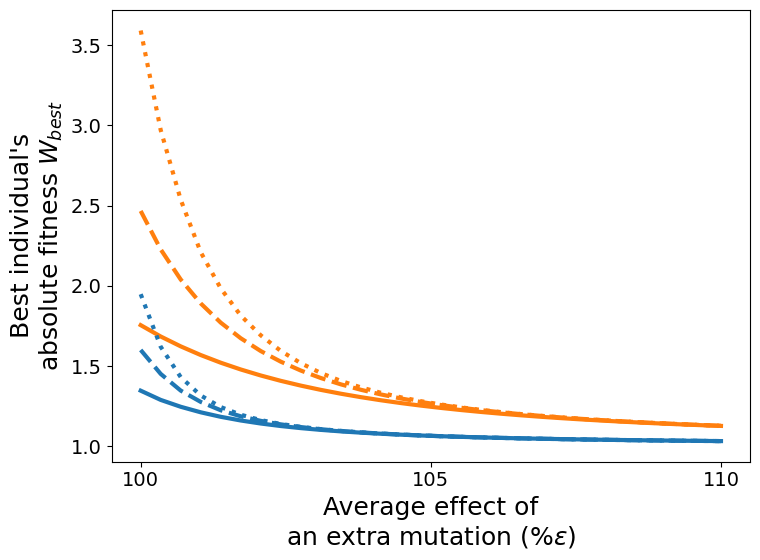

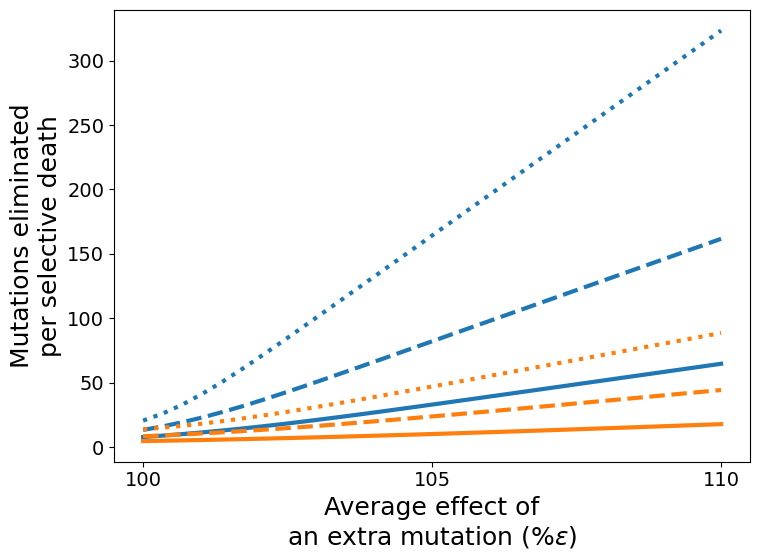

In [7]:
# Combine arrays into a DataFrame
df = pd.DataFrame({
    'Ud': allUds,
    'sd': allsds,
    'Wbest': Wbest,
    'epistasis_degree': allepistasis,
    'eliminatedperselectivedeaths': eliminatedperselectivedeaths
    #'IQFoldDifference': interquantile_folddifference,
    #'Q25improvementoverQ75': Q25improvementoverQ75
})

x_values = [1.0, 1.05, 1.1]
x_labels = ['100', '105', '110']

linetypes = ['-', '--', ':']
colorslist = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

legend_elements = [Line2D([0], [0], color=colorslist[0], lw=4, label=r'$U_{d} = 2.0$'),
                Line2D([0], [0], color=colorslist[1], lw=4, label=r'$U_{d} = 5.0$'),
                Line2D([0], [0], color=colorslist[2], lw=4, label=r'$U_{d} = 10.0$'),
                Line2D([0], [0], color='black', linestyle=linetypes[0], lw=4, label='lower bound ' + r'$s_{d}$'),
                Line2D([0], [0], color='black', linestyle=linetypes[1], lw=4, label='upper bound ' + r'$s_{d}$'),
                Line2D([0], [0], color='black', linestyle=linetypes[2], lw=4, label='Boyko ' + r'$s_{d}$')
                ]

legend_elements = [Line2D([0], [0], color=colorslist[0], lw=4, label='lower bound ' + r'$s_{d}$'),
                Line2D([0], [0], color=colorslist[1], lw=4, label='upper bound ' + r'$s_{d}$'),
                Line2D([0], [0], color=colorslist[2], lw=4, label='Boyko ' + r'$s_{d}$'),
                Line2D([0], [0], color='black', linestyle=linetypes[0], lw=4, label=r'$U_{d} = 2.0$'),
                Line2D([0], [0], color='black', linestyle=linetypes[1], lw=4, label=r'$U_{d} = 5.0$'),
                Line2D([0], [0], color='black', linestyle=linetypes[2], lw=4, label=r'$U_{d} = 10.0$')
                ]

# Create the legend figure
fig = plt.figure(figsize=(8, 6))
ax = fig.gca()

ax.legend(handles=legend_elements, loc='center')

fig.savefig('graphs/legend_negativeepistasis.png', bbox_inches='tight') 

plt.show()
plt.close()

df = df[df['sd'] != Boyko_sd] # Exclude Boyko's sd for the plots
fig = plt.figure(figsize=(8, 6))
ax = fig.gca()
i=0            
for Ud_value in df['Ud'].unique():
    j=0
    for sd_value in df['sd'].unique():
        subset_df = df[(df['Ud'] == Ud_value) & (df['sd'] == sd_value)]
        if not subset_df.empty:
            plt.plot(subset_df['epistasis_degree'], subset_df['Wbest'],
                        linestyle=linetypes[i], # Default to solid if not in map
                        color=colorslist[j])
        j += 1
    i += 1
ax.xaxis.set_ticks(x_values)
ax.xaxis.set_ticklabels(x_labels)
ax.set_xlabel('Average effect of\nan extra mutation (%' + r'$\epsilon$' + ')')
plt.ylabel('Best individual\'s\nabsolute fitness ' + r'$W_{best}$')
plt.tight_layout()

fig.savefig('graphs/Wbest_negativeepistasis.png', bbox_inches='tight') 
plt.show()
plt.close()

fig = plt.figure(figsize=(8, 6))
ax = fig.gca()
i=0            
for Ud_value in df['Ud'].unique():
    j=0
    for sd_value in df['sd'].unique():
        subset_df = df[(df['Ud'] == Ud_value) & (df['sd'] == sd_value)]
        if not subset_df.empty:
            plt.plot(subset_df['epistasis_degree'], subset_df['eliminatedperselectivedeaths'],
                        linestyle=linetypes[i], # Default to solid if not in map
                        color=colorslist[j])
        j += 1
    i += 1
ax.xaxis.set_ticks(x_values)
ax.xaxis.set_ticklabels(x_labels)
ax.set_xlabel('Average effect of\nan extra mutation (%' + r'$\epsilon$' + ')')
plt.ylabel('Mutations eliminated\nper selective death')
plt.tight_layout()

fig.savefig('graphs/Eliminatedperselectivedeath_negativeepistasis.png', bbox_inches='tight') 
plt.show()
plt.close()